# Alunos
Fernando Bianchi - 00335450

Mateus Pletsch - 00338372

# Setup

In [1]:
!git clone https://github.com/Febianchi/fernando-matheus

Cloning into 'fernando-matheus'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 35 (delta 9), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 10.29 MiB | 20.54 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
%cd fernando-matheus/

/content/fernando-matheus


In [3]:
!pip install pylhe
#!pip install git+https://github.com/scikit-hep/pylhe.git --quiet
!pip install matplotlib numpy --quiet
!pip install pylhe awkward vector
!gzip -d -k -f {'data/sinal.lhe.gz'} # unpack files
!gzip -d -k -f {'data/fundo.lhe.gz'}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 909.5/909.5 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.0/308.0 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.3/181.3 kB 13.8 MB/s eta 0:00:00


In [4]:
import pylhe
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools
from pathlib import Path
from pprint import pprint
import gzip

# Tabela do PDG

| ID | Partícula | Símbolo | Tipo |
| :---: | :--- | :---: | :--- |
| **1** | Down Quark | $d$ | Quark |
| **2** | Up Quark | $u$ | Quark |
| **3** | Strange Quark | $s$ | Quark |
| **4** | Charm Quark | $c$ | Quark |
| **5** | Bottom Quark | $b$ | Quark |
| **6** | Top Quark | $t$ | Quark |
| | | | |
| **11** | Elétron | $e^-$ | Lépton |
| **12** | Neutrino do Elétron | $\nu_e$ | Lépton |
| **13** | Múon | $\mu^⁻$ | Lépton |
| **14** | Neutrino do Múon | $\nu_\mu$ | Lépton |
| **15** | Tau | $\tau^-$ | Lépton |
| **16** | Neutrino do Tau | $\nu_\tau$ | Lépton |
| | | | |
| **21** | Glúon | $g$ | Bóson |
| **22** | Fóton | $\gamma$ | Bóson |
| **23** | Z Boson | $Z^0$ | Bóson |
| **24** | W Boson | $W^+$ | Bóson |
| **25** | Higgs Boson | $H$ | Bóson |

---
**Regra dos Sinais:**
* **Positivo (+):** Partícula (ex: `6` é o Top).
* **Negativo (-):** Antipartícula (ex: `-6` é o Anti-Top, `-24` é o $W^-$).
* **Exceção:** Glúons e Bosons Z/H/Fóton são suas próprias antipartículas (ou não têm distinção de carga no ID básico), então geralmente aparecem positivos.

In [5]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

def lhe_to_dataframe(filename, label_processo):
    """
    Lê um arquivo .lhe e retorna um DataFrame onde cada linha é uma partícula.
    Adiciona uma coluna 'label' para distinguir Sinal de Background.
    """
    data = []
    event_id = 0
    in_event = False

    print(f"Lendo arquivo: {filename} ...")

    # Usar gzip.open para lidar com arquivos .gz
    with gzip.open(filename, 'rt') as f: # 'rt' para ler como texto
        for line in f:
            # Controle de bloco de evento
            if '<event>' in line:
                in_event = True
                event_id += 1
                continue
            if '</event>' in line:
                in_event = False
                continue

            # Processamento das linhas de partículas
            if in_event:
                parts = line.strip().split()
                # Validação simples: linhas de partícula têm muitas colunas (aprox 13)
                # A primeira linha pós <event> é cabeçalho do evento (poucas colunas), ignoramos.
                if len(parts) > 6:
                    data.append({
                        'event_id': event_id,
                        'pdg_id': int(parts[0]),
                        'status': int(parts[1]),
                        # Px, Py, Pz, E estão nas colunas 6, 7, 8, 9 (índice base 0)
                        'px': float(parts[6]),
                        'py': float(parts[7]),
                        'pz': float(parts[8]),
                        'e': float(parts[9]),
                        'mass': float(parts[10]),
                        'label': label_processo
                    })

    df = pd.DataFrame(data)
    print(f"Concluído! {len(df)} partículas carregadas.")
    return df

In [6]:
# --- 1. LEITURA ---
df_sinal = lhe_to_dataframe('data/sinal.lhe.gz', 'Sinal')
df_back  = lhe_to_dataframe('data/fundo.lhe.gz', 'Background')

# Concatenando para facilitar cálculos gerais
df_total = pd.concat([df_sinal, df_back], ignore_index=True)

# --- 2a. CONTAGEM DE EVENTOS ---
n_ev_sinal = df_sinal['event_id'].nunique()
n_ev_back = df_back['event_id'].nunique()

print(f"\n--- Resumo de Eventos ---")
print(f"Total Eventos Sinal: {n_ev_sinal}")
print(f"Total Eventos Background: {n_ev_back}")

Lendo arquivo: data/sinal.lhe.gz ...
Concluído! 150000 partículas carregadas.
Lendo arquivo: data/fundo.lhe.gz ...
Concluído! 150000 partículas carregadas.

--- Resumo de Eventos ---
Total Eventos Sinal: 10000
Total Eventos Background: 10000


In [7]:
# 1. Definição do Mapa (conforme você forneceu)
pdg_map = {
    1: 'd', 2: 'u', 3: 's', 4: 'c', 5: 'b', 6: 'Top',
    -1: 'd~', -2: 'u~', -3: 's~', -4: 'c~', -5: 'b~', -6: 'Top~',
    11: 'e-', -11: 'e+', 12: 'nu_e', -12: 'nu_e~',
    13: 'mu-', -13: 'mu+', 14: 'nu_mu', -14: 'nu_mu~',
    15: 'tau-', -15: 'tau+', 16: 'nu_tau', -16: 'nu_tau~',
    21: 'Gluon', 22: 'Photon', 23: 'Z', 24: 'W+', -24: 'W-', 25: 'Higgs'
}

# 2. Criar a coluna 'particle_name' nos DataFrames
# O método .map() pega o valor de 'pdg_id' e busca a chave correspondente no dicionário
df_sinal['particle_name'] = df_sinal['pdg_id'].map(pdg_map)
df_back['particle_name'] = df_back['pdg_id'].map(pdg_map)

# --- 2b. TABELA DE PARTÍCULAS (ATUALIZADA) ---

print("\n--- Conteúdo do SINAL (Status vs PDG vs Nome) ---")
# Agrupamos agora por 3 colunas: status, pdg_id e o nome
# O .fillna('Unknown') garante que se algum ID não estiver no mapa, não quebre o código
print(df_sinal.groupby(['status', 'pdg_id', 'particle_name']).size().to_string())

print("\n--- Conteúdo do BACKGROUND (Status vs PDG vs Nome) ---")
print(df_back.groupby(['status', 'pdg_id', 'particle_name']).size().to_string())


--- Conteúdo do SINAL (Status vs PDG vs Nome) ---
status  pdg_id  particle_name
-1      -4      c~                  53
        -3      s~                  78
        -2      u~                1529
        -1      d~                 945
         1      d                  945
         2      u                 1529
         3      s                   78
         4      c                   53
         21     Gluon            14790
 1      -13     mu+               5065
        -11     e+                4935
        -5      b~               20000
        -4      c~                5099
        -2      u~                4901
         1      d                 4901
         3      s                 5099
         5      b                20000
         12     nu_e              4935
         14     nu_mu             5065
 2      -24     W-               10000
        -6      Top~             10000
         6      Top              10000
         24     W+               10000
         25     Higgs 

In [8]:
# Ou podemos usar diretamente a funcionalidade do pandas, mas sem organizar por grupo:
df_sinal[['pdg_id', 'status']]

,pdg_id,status
0,2,-1
1,-2,-1
2,6,2
3,-6,2
4,25,2
...,...,...
149995,24,2
149996,-11,1
149997,12,1
149998,5,1


## Qual é o processo de sinal?
Sabemos que os arquivos .lhe contêm 10.000 eventos cada. Observamos que o bóson de Higgs aparece 10.000 vezes como estado intermediário, acompanhado pela produção de um par top–antitop. Portanto, esse arquivo corresponde à produção de eventos envolvendo um Higgs intermediário.

Um dos canais de decaimento do Higgs é em bósons W⁺ e W⁻. Isso explica por que também encontramos cerca de 10.000 ocorrências de W⁺ e W⁻, assim como 20.000 quarks b e b̄: eles são produtos diretos dos decaimentos dos Higgs gerados.

A razão das contagens de evntos em outros léptons é porque os bósons W⁺ e W⁻ decaem em léptons (e⁺, μ⁺), neutrinos, e também em quarks leves (d, s, c, u), dependendo do canal de decaimento.

Em resumo, temos a reação:
pp → t ̄t H → bW+ ̄bW- b ̄b

## Qual é o processo do fundo?
Sabemos que os arquivos .lhe contêm 10.000 eventos cada. Observamos que o bóson Z aparece 10.000 vezes como estado intermediário, acompanhado pela produção de um par top–antitop. Portanto, esse arquivo corresponde à produção de eventos envolvendo um bóson Z intermediário.

Os tops decaem naturalmente em bósons W e quarks b. Além disso, o canal de decaimento do bóson Z simulado aqui é em par quark–antiquark (bbˉ). Isso explica por que também encontramos cerca de 10.000 ocorrências de W⁺ e W⁻, assim como 20.000 pares de quarks b e b̄ (40.000 no total): eles são produtos combinados dos decaimentos dos tops e do bóson Z gerado.

A razão das contagens de eventos em outros léptons é porque os bósons W⁺ e W⁻ decaem em léptons (e⁺, μ⁺), neutrinos, e também em quarks leves (d, s, c, u), dependendo do canal de decaimento.

Em resumo, temos a reação:
pp→ t ̄t Z→ bW+ ̄bW− b ̄b

### Pergunta:
Os histogramas representam todos os eventos do arquivo LHE?  
Se não, explique o porquê (por exemplo: presença ou ausência de certas partículas nos eventos).

Não, os histogramas não representam todos os eventos do arquivo LHE. Primeiramente, só foram utilizados os eventos correspondentes aos estados finais, ou seja, os léptons que surgiram de decaimentos intermediários (status==1). Além disso, como solicitado nas instruções, foram ignorados os neutrinos (embora os neutrinos não sejam detectados de qualquer maneira) durante a construção dos histogramas.

# [4] Filtros e Cortes Cinemáticos

<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-3286502513.py:44: SyntaxWarning: invalid escape sequence '\e'
  plot_comparacao('eta', 'Pseudorapidez $\eta$', (-3, 3))
/tmp/ipython-input-3286502513.py:45: SyntaxWarning: invalid escape sequence '\p'
  plot_comparacao('phi', 'Ângulo Azimutal $\phi$', (-np.pi, np.pi))


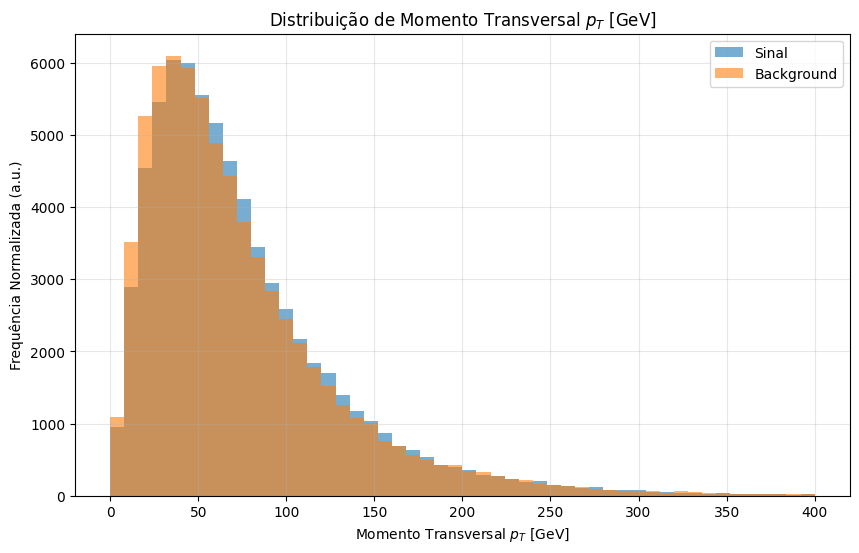

Eventos no plot (Momento Transversal $p_T$ [GeV]): Sinal=70000, Back=70000


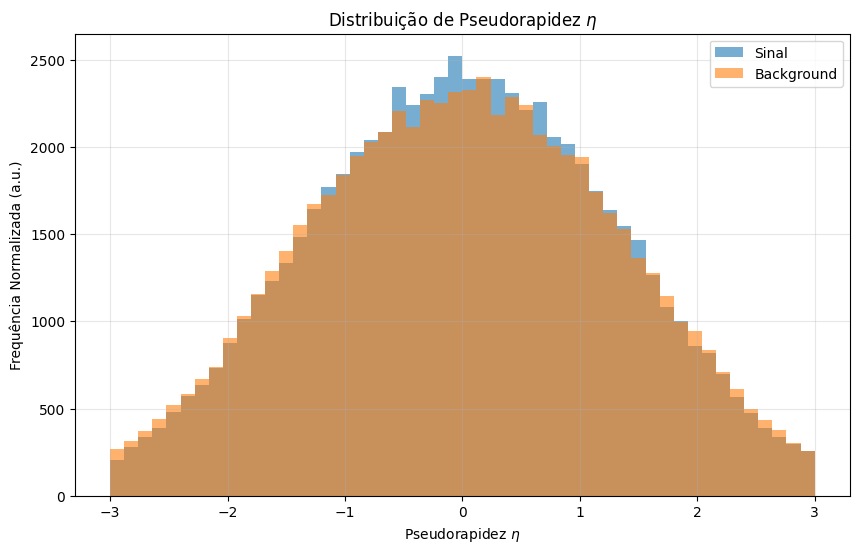

Eventos no plot (Pseudorapidez $\eta$): Sinal=70000, Back=70000


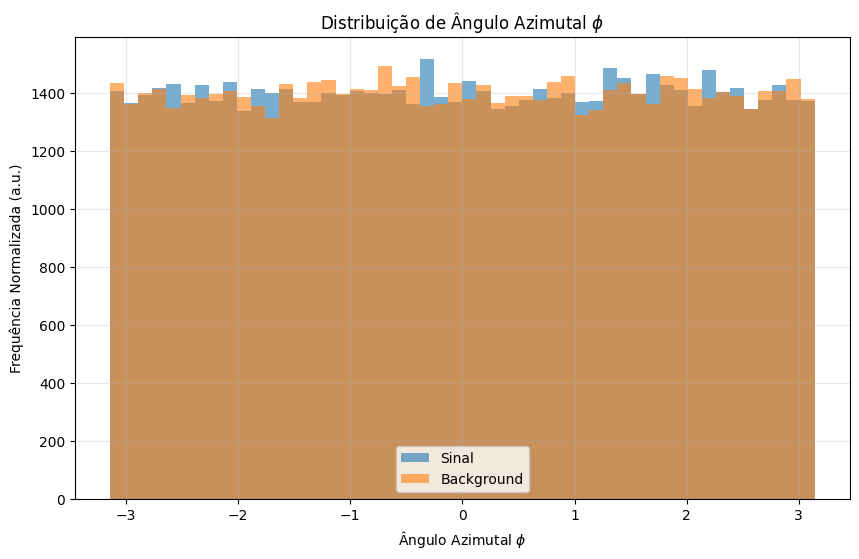

Eventos no plot (Ângulo Azimutal $\phi$): Sinal=70000, Back=70000


In [9]:
# --- CÁLCULOS CINEMÁTICOS (Vetorizados) ---
# pT = raiz(px² + py²)
df_total['pt'] = np.sqrt(df_total['px']**2 + df_total['py']**2)

# Eta (Pseudorapidez) = arcsinh(pz/pt)
# Adicionamos 1e-10 para evitar erro de divisão por zero se pT=0
df_total['eta'] = np.arcsinh(df_total['pz'] / (df_total['pt'] + 1e-10))

# Phi (Azimutal)
df_total['phi'] = np.arctan2(df_total['py'], df_total['px'])

# --- FILTROS DE PLOTAGEM ---
# As instruções pedem:
# 1. Estado Final (status == 1)
# 2. Excluir Neutrinos (PDG IDs: 12, 14, 16 e seus negativos)
neutrinos = [12, 14, 16]
mask_visivel = (df_total['status'] == 1) & (~df_total['pdg_id'].abs().isin(neutrinos))

df_plot = df_total[mask_visivel]

# --- FUNÇÃO PARA PLOTAR HISTOGRAMAS ---
def plot_comparacao(variavel, label_x, range_plot, bins=50):
    plt.figure()

    # Separa os dados filtrados em sinal e background
    dados_sinal = df_plot[df_plot['label'] == 'Sinal'][variavel]
    dados_back  = df_plot[df_plot['label'] == 'Background'][variavel]

    # Plota
    plt.hist(dados_sinal, bins=bins, range=range_plot, alpha=0.6, label='Sinal', histtype='stepfilled')
    plt.hist(dados_back,  bins=bins, range=range_plot, alpha=0.6, label='Background', histtype='stepfilled')

    plt.xlabel(label_x)
    plt.ylabel('Frequência Normalizada (a.u.)')
    plt.title(f'Distribuição de {label_x}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Eventos no plot ({label_x}): Sinal={len(dados_sinal)}, Back={len(dados_back)}")

# Gerando os Gráficos pedidos
plot_comparacao('pt', 'Momento Transversal $p_T$ [GeV]', (0, 400))
plot_comparacao('eta', 'Pseudorapidez $\eta$', (-3, 3))
plot_comparacao('phi', 'Ângulo Azimutal $\phi$', (-np.pi, np.pi))

### Pergunta:
Os histogramas representam todos os eventos do arquivo LHE?  
Se não, explique o porquê (por exemplo: presença ou ausência de certas partículas nos eventos).

Não, os histogramas não representam todos os eventos do arquivo LHE. Primeiramente, só foram utilizados os eventos correspondentes aos estados finais, ou seja, os léptons que surgiram de decaimentos intermediários (status==1). Além disso, como solicitado nas instruções, foram ignorados os neutrinos (embora os neutrinos não sejam detectados de qualquer maneira) durante a construção dos histogramas.

# [4] Filtros e Cortes Cinemáticos

<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:49: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1960631920.py:46: SyntaxWarning: invalid escape sequence '\e'
  ax[1].axvline(ETA_MAX, color='k', linestyle='--', label=f'|$\eta$| < {ETA_MAX}')
/tmp/ipython-input-1960631920.py:48: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_title(f"Pseudorapidez ($|\eta| < {ETA_MAX}$)")
/tmp/ipython-input-1960631920.py:49: SyntaxWarning: invalid escape sequence '\e'
  ax[1].set_xlabel("$\eta$")
/tmp/ipython-input-1960631920.py:55: SyntaxWarning: invalid escape sequence 

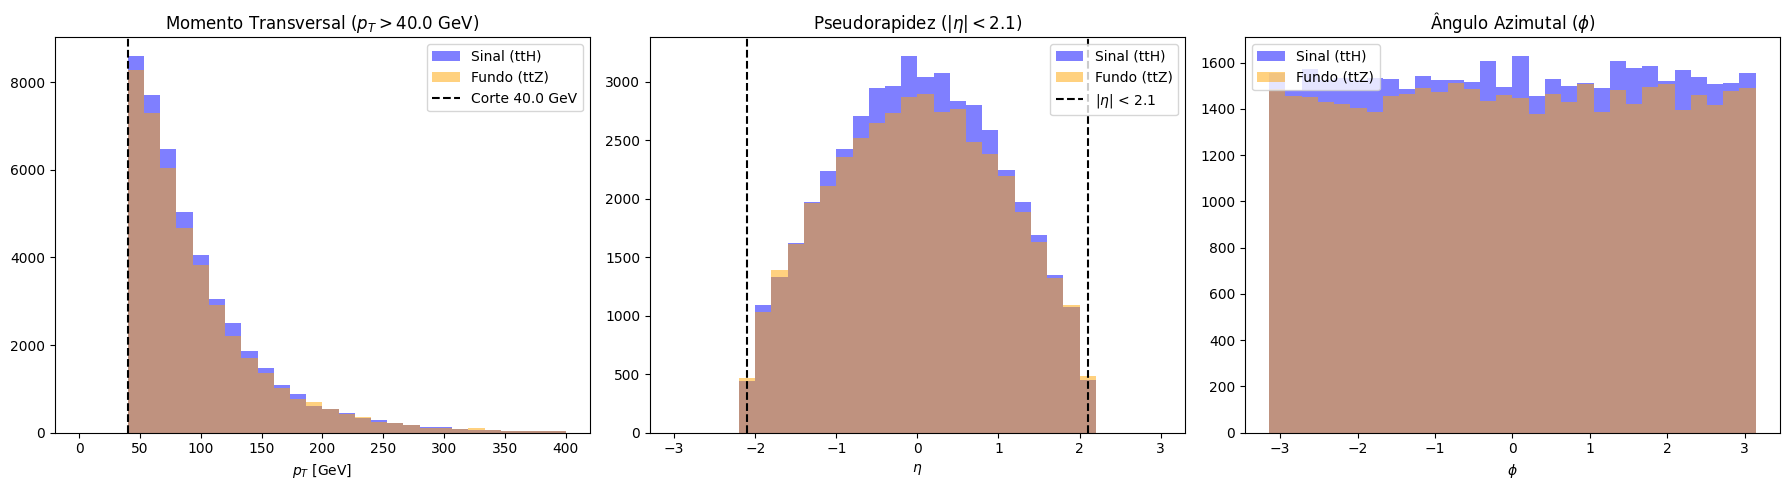


Corte realizado pT > 40.0
Corte realizado em |eta| < 2.1
ANÁLISE DE EFICIÊNCIA DOS CORTES (VIA PANDAS)
SINAL (ttH):
  - Partículas Totais: 70000
  - Partículas Aceitas: 46049
  - Perda: 34.22% das partículas foram cortadas.
------------------------------
FUNDO (ttZ):
  - Partículas Totais: 70000
  - Partículas Aceitas: 43564
  - Perda: 37.77% das partículas foram cortadas.


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Configuração dos Cortes ---
PT_MIN = 40.0   # GeV
ETA_MAX = 2.1   # Módulo máximo

# --- 2. Aplicação dos Cortes no DataFrame ---
# Criamos uma "máscara" booleana que exige AMBAS as condições (AND lógico '&')
# Condição 1: pT maior que o mínimo
# Condição 2: Valor absoluto de eta menor que o máximo
mask_cortes = (df_plot['pt'] > PT_MIN) & (df_plot['eta'].abs() < ETA_MAX)

# Aplica a máscara para criar o novo dataframe
df_cortado = df_plot[mask_cortes]

# --- 3. Cálculo de Estatísticas (Total vs Aceito) ---
# Contagem Inicial (Antes do corte)
s_tot = len(df_plot[df_plot['label'] == 'Sinal'])
f_tot = len(df_plot[df_plot['label'] == 'Background'])

# Contagem Final (Depois do corte)
s_ok = len(df_cortado[df_cortado['label'] == 'Sinal'])
f_ok = len(df_cortado[df_cortado['label'] == 'Background'])

# --- 4. Plotagem (Usando o DataFrame Cortado) ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
kwargs = dict(alpha=0.5, bins=30, ec="k")

# Separando os dados cortados para facilitar o plot
sinal_data = df_cortado[df_cortado['label'] == 'Sinal']
bkg_data = df_cortado[df_cortado['label'] == 'Background']

# --- Plot 1: pT ---
ax[0].hist(sinal_data['pt'], range=(0, 400), color='blue', label='Sinal (ttH)', **kwargs)
ax[0].hist(bkg_data['pt'], range=(0, 400), color='orange', label='Fundo (ttZ)', **kwargs)
ax[0].axvline(PT_MIN, color='k', linestyle='--', label=f'Corte {PT_MIN} GeV')
ax[0].set_title(f"Momento Transversal ($p_T > {PT_MIN}$ GeV)")
ax[0].set_xlabel("$p_T$ [GeV]")
ax[0].legend()

# --- Plot 2: Eta ---
ax[1].hist(sinal_data['eta'], range=(-3, 3), color='blue', label='Sinal (ttH)', **kwargs)
ax[1].hist(bkg_data['eta'], range=(-3, 3), color='orange', label='Fundo (ttZ)', **kwargs)
ax[1].axvline(ETA_MAX, color='k', linestyle='--', label=f'|$\eta$| < {ETA_MAX}')
ax[1].axvline(-ETA_MAX, color='k', linestyle='--')
ax[1].set_title(f"Pseudorapidez ($|\eta| < {ETA_MAX}$)")
ax[1].set_xlabel("$\eta$")
ax[1].legend()

# --- Plot 3: Phi ---
ax[2].hist(sinal_data['phi'], range=(-np.pi, np.pi), color='blue', label='Sinal (ttH)', **kwargs)
ax[2].hist(bkg_data['phi'], range=(-np.pi, np.pi), color='orange', label='Fundo (ttZ)', **kwargs)
ax[2].set_title("Ângulo Azimutal ($\phi$)")
ax[2].set_xlabel("$\phi$")
ax[2].legend()

plt.tight_layout()
plt.show()

# --- 5. Relatório de Eficiência ---
print("\n" + "="*60)
print(f"Corte realizado pT > {PT_MIN}")
print(f"Corte realizado em |eta| < {ETA_MAX}")
print("ANÁLISE DE EFICIÊNCIA DOS CORTES (VIA PANDAS)")
print("="*60)
print(f"SINAL (ttH):")
print(f"  - Partículas Totais: {s_tot}")
print(f"  - Partículas Aceitas: {s_ok}")
print(f"  - Perda: {100*(s_tot-s_ok)/s_tot:.2f}% das partículas foram cortadas.")
print("-" * 30)
print(f"FUNDO (ttZ):")
print(f"  - Partículas Totais: {f_tot}")
print(f"  - Partículas Aceitas: {f_ok}")
print(f"  - Perda: {100*(f_tot-f_ok)/f_tot:.2f}% das partículas foram cortadas.")
print("="*60)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# APLICAÇÃO DOS CORTES CINEMÁTICOS
# Critérios: pT > 40.0 GeV E |eta| < 2.1
# ==============================================================================

def aplicar_cortes(df):
    """
    Calcula pT e Eta, e filtra o dataframe conforme os critérios.
    Retorna um novo dataframe contendo apenas as partículas que passam nos cortes.
    """
    # 1. Calcular pT e P total
    df['pt'] = np.sqrt(df['px']**2 + df['py']**2)
    p = np.sqrt(df['px']**2 + df['py']**2 + df['pz']**2)

    # 2. Calcular Eta (Pseudorapidez) com segurança numérica
    # eta = 0.5 * ln((p + pz) / (p - pz))
    with np.errstate(divide='ignore', invalid='ignore'):
        df['eta'] = 0.5 * np.log((p + df['pz']) / (p - df['pz']))
        # Substituir infinitos (caso pz ~ p, feixe) por NaN
        df['eta'] = df['eta'].replace([np.inf, -np.inf], np.nan)

    # 3. Definir a máscara de seleção
    # Status = 1 (Final)
    # Não Neutrinos (12, 14, 16)
    # pT > 40.0
    # |eta| < 2.1
    neutrinos = [12, 14, 16]
    mask = (df['status'] == 1) & \
           (~df['pdg_id'].abs().isin(neutrinos)) & \
           (df['pt'] > 40.0) & \
           (df['eta'].abs() < 2.1)

    # Retorna apenas as linhas que satisfazem TODAS as condições
    return df[mask].copy()

print("Aplicando cortes cinemáticos...")
df_sinal_sel = aplicar_cortes(df_sinal)
df_back_sel  = aplicar_cortes(df_back)

df_sinal = df_sinal_sel
df_back  = df_back_sel

del df_sinal_sel
del df_back_sel

Aplicando cortes cinemáticos...


# [5] CONSERVAÇÃO DE ENERGIA

In [13]:
import numpy as np
import pandas as pd

# --- [5] CONSERVAÇÃO DE ENERGIA ---

# 1. Definir os índices alvo: 1 + 1000*i para i de 0 a 9
indices_alvo = [1 + 1000 * i for i in range(10)]
neutrinos_ids = [12, 14, 16]

def calcular_e_imprimir_s(df, nome_processo):
    """
    Calcula e imprime a variável de Mandelstam 's' para eventos específicos de um dataframe.
    """
    print(f"\n>>> Processo: {nome_processo}")
    print(f"{'Evento ID':<10} | {'s (GeV²)' :<20} | {'sqrt(s) (GeV)':<20}")
    print("-" * 55)

    # Filtrar apenas partículas finais visíveis (status 1 e não neutrinos)
    # Isso é feito uma vez para o dataframe todo para otimizar
    mask_visivel = (df['status'] == 1) & (~df['pdg_id'].abs().isin(neutrinos_ids))
    df_visivel = df[mask_visivel]

    for evt_id in indices_alvo:
        # Seleciona as partículas do evento específico
        particulas = df_visivel[df_visivel['event_id'] == evt_id]

        if particulas.empty:
            # Caso o evento não tenha partículas visíveis (raro, mas possível)
            print(f"{evt_id:<10} | {'Vazio/N/A':<20} | {'-'}")
            continue

        # Soma dos quadrimomentos (Energia e Momento)
        E_tot  = particulas['e'].sum()
        Px_tot = particulas['px'].sum()
        Py_tot = particulas['py'].sum()
        Pz_tot = particulas['pz'].sum()

        # Cálculo de s = E² - p²
        p2 = Px_tot**2 + Py_tot**2 + Pz_tot**2
        s_value = E_tot**2 - p2

        # sqrt(s) para visualização da massa invariante do sistema visível
        # max(0, ...) evita erro matemático em caso de flutuação numérica negativa muito pequena
        sqrt_s = np.sqrt(max(0, s_value))

        print(f"{evt_id:<10} | {s_value:<20.4e} | {sqrt_s:<20.4f}")

# Executar para o SINAL
calcular_e_imprimir_s(df_sinal, "SINAL (ttH)")

# Executar para o FUNDO
calcular_e_imprimir_s(df_back, "FUNDO (ttZ)")


>>> Processo: SINAL (ttH)
Evento ID  | s (GeV²)             | sqrt(s) (GeV)       
-------------------------------------------------------
1          | 1.0712e+06           | 1034.9922           
1001       | 2.6647e+05           | 516.2053            
2001       | 1.6638e+05           | 407.8923            
3001       | 1.1318e+06           | 1063.8541           
4001       | 1.7864e+05           | 422.6575            
5001       | 4.5725e+05           | 676.2024            
6001       | 2.8370e+05           | 532.6340            
7001       | 3.6421e+05           | 603.5017            
8001       | 8.1275e+05           | 901.5263            
9001       | 2.1433e+05           | 462.9583            

>>> Processo: FUNDO (ttZ)
Evento ID  | s (GeV²)             | sqrt(s) (GeV)       
-------------------------------------------------------
1          | 5.4158e+05           | 735.9219            
1001       | 1.3881e+06           | 1178.1794           
2001       | 5.7919e+05           | 

# [6] RECONSTRUÇÃO DE VARIÁVEIS

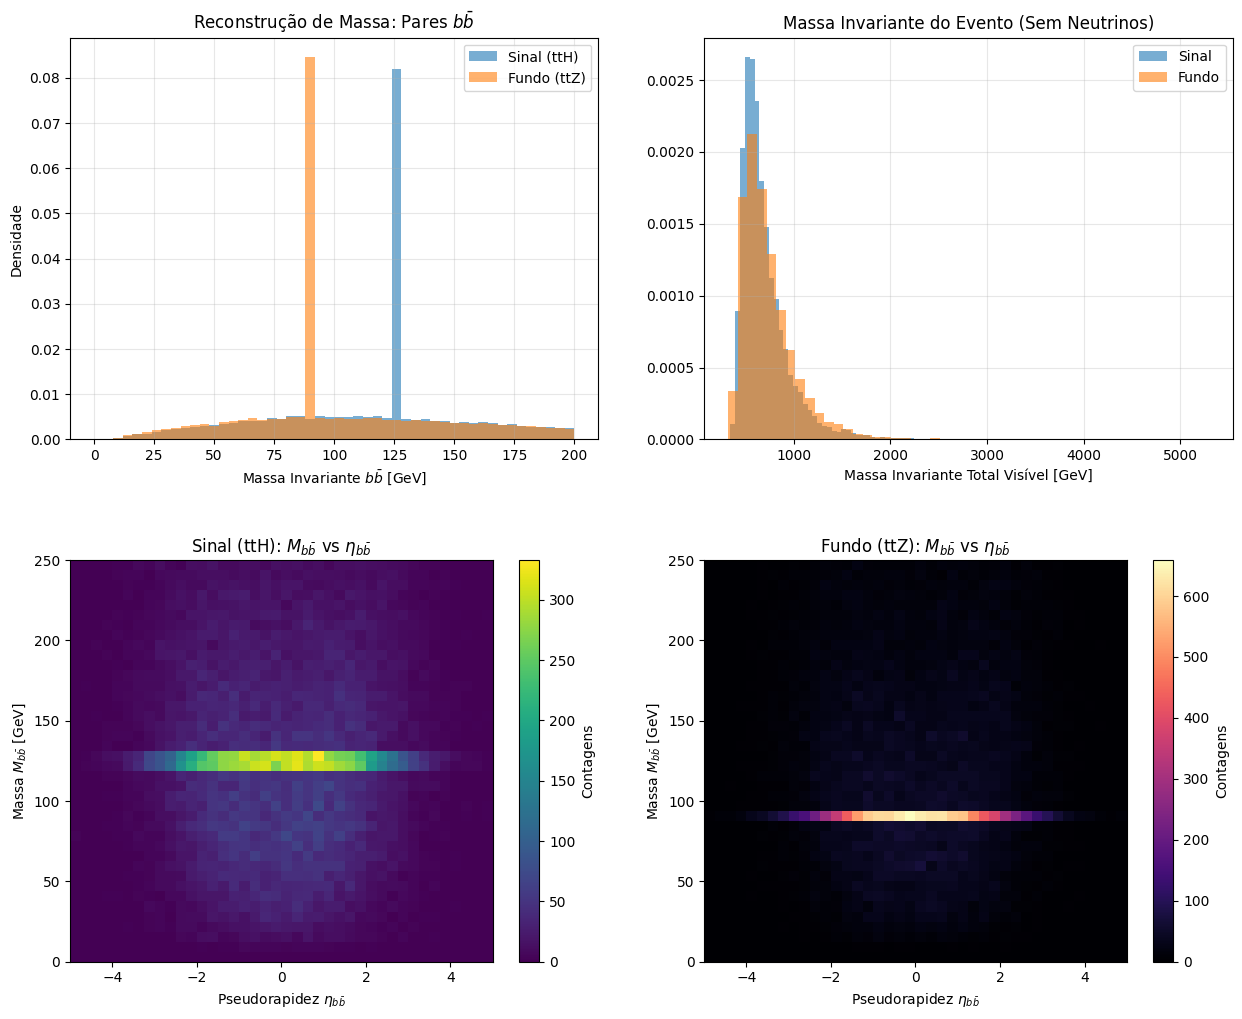

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- [6] RECONSTRUÇÃO DE VARIÁVEIS ---

# 1. Preparação dos Dados para Pares b-bbar
# Filtrar quarks b (5) e anti-b (-5) com status 1 (estado final no parton level)
quarks_b = df_total[(df_total['pdg_id'] == 5) & (df_total['status'] == 1)]
quarks_bbar = df_total[(df_total['pdg_id'] == -5) & (df_total['status'] == 1)]

# Renomear colunas para distinguir partícula 1 e 2 no par
# Mantemos 'event_id' e 'label' para garantir que o par seja do mesmo evento e processo
cols_join = ['event_id', 'label']
cols_keep = ['e', 'px', 'py', 'pz']

b_renamed = quarks_b[cols_join + cols_keep].rename(
    columns={'e': 'e1', 'px': 'px1', 'py': 'py1', 'pz': 'pz1'}
)
bbar_renamed = quarks_bbar[cols_join + cols_keep].rename(
    columns={'e': 'e2', 'px': 'px2', 'py': 'py2', 'pz': 'pz2'}
)

# Criar os pares (Produto Cartesiano dentro de cada evento)
# Isso gera todas as combinações b + bbar possíveis por evento
df_pairs = pd.merge(b_renamed, bbar_renamed, on=cols_join)

# --- Cálculos Cinemáticos para o Par ---
# Energia e Momento Total do Par
df_pairs['E_par']  = df_pairs['e1'] + df_pairs['e2']
df_pairs['Px_par'] = df_pairs['px1'] + df_pairs['px2']
df_pairs['Py_par'] = df_pairs['py1'] + df_pairs['py2']
df_pairs['Pz_par'] = df_pairs['pz1'] + df_pairs['pz2']

# Massa Invariante: M² = E² - |p|²
df_pairs['P2_par'] = df_pairs['Px_par']**2 + df_pairs['Py_par']**2 + df_pairs['Pz_par']**2
df_pairs['M_bb'] = np.sqrt((df_pairs['E_par']**2 - df_pairs['P2_par']).clip(lower=0))

# Pseudorapidez (Eta) do Par
# eta = arctanh(pz / |p|)
P_mod = np.sqrt(df_pairs['P2_par'])
with np.errstate(divide='ignore', invalid='ignore'):
    df_pairs['eta_bb'] = np.arctanh(df_pairs['Pz_par'] / P_mod)


# 2. Preparação da Massa Total Visível
neutrinos = [12, 14, 16]
mask_visible = (df_total['status'] == 1) & (~df_total['pdg_id'].abs().isin(neutrinos))
df_vis = df_total[mask_visible]

# Agrupar por evento para somar quadrimomentos de todas as partículas
df_evt = df_vis.groupby(['event_id', 'label'])[['e', 'px', 'py', 'pz']].sum().reset_index()

# Massa Invariante Total
df_evt['P2_tot'] = df_evt['px']**2 + df_evt['py']**2 + df_evt['pz']**2
df_evt['M_total'] = np.sqrt((df_evt['e']**2 - df_evt['P2_tot']).clip(lower=0))


# --- PLOTAGEM ---

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# Plot 1: Massa Invariante de Pares b-bbar
# Mostra picos de ressonância (Z e Higgs)
axs[0,0].hist(df_pairs[df_pairs['label'] == 'Sinal']['M_bb'], bins=50, range=(0, 200),
              alpha=0.6, label='Sinal (ttH)', density=True, histtype='stepfilled')
axs[0,0].hist(df_pairs[df_pairs['label'] == 'Background']['M_bb'], bins=50, range=(0, 200),
              alpha=0.6, label='Fundo (ttZ)', density=True, histtype='stepfilled')
axs[0,0].set_xlabel('Massa Invariante $b\\bar{b}$ [GeV]')
axs[0,0].set_ylabel('Densidade')
axs[0,0].set_title('Reconstrução de Massa: Pares $b\\bar{b}$')
axs[0,0].legend()
axs[0,0].grid(alpha=0.3)

# Plot 2: Massa Invariante Total do Evento
axs[0,1].hist(df_evt[df_evt['label'] == 'Sinal']['M_total'], bins=50,
              alpha=0.6, label='Sinal', density=True, histtype='stepfilled')
axs[0,1].hist(df_evt[df_evt['label'] == 'Background']['M_total'], bins=50,
              alpha=0.6, label='Fundo', density=True, histtype='stepfilled')
axs[0,1].set_xlabel('Massa Invariante Total Visível [GeV]')
axs[0,1].set_title('Massa Invariante do Evento (Sem Neutrinos)')
axs[0,1].legend()
axs[0,1].grid(alpha=0.3)

# Plot 3: Mapa de Calor (Sinal) - Massa bb vs Eta bb
sinal_p = df_pairs[df_pairs['label'] == 'Sinal']
h1 = axs[1,0].hist2d(sinal_p['eta_bb'], sinal_p['M_bb'], bins=40, range=[[-5, 5], [0, 250]], cmap='viridis')
fig.colorbar(h1[3], ax=axs[1,0], label='Contagens')
axs[1,0].set_xlabel('Pseudorapidez $\\eta_{b\\bar{b}}$')
axs[1,0].set_ylabel('Massa $M_{b\\bar{b}}$ [GeV]')
axs[1,0].set_title('Sinal (ttH): $M_{b\\bar{b}}$ vs $\\eta_{b\\bar{b}}$')

# Plot 4: Mapa de Calor (Fundo) - Massa bb vs Eta bb
back_p = df_pairs[df_pairs['label'] == 'Background']
h2 = axs[1,1].hist2d(back_p['eta_bb'], back_p['M_bb'], bins=40, range=[[-5, 5], [0, 250]], cmap='magma')
fig.colorbar(h2[3], ax=axs[1,1], label='Contagens')
axs[1,1].set_xlabel('Pseudorapidez $\\eta_{b\\bar{b}}$')
axs[1,1].set_ylabel('Massa $M_{b\\bar{b}}$ [GeV]')
axs[1,1].set_title('Fundo (ttZ): $M_{b\\bar{b}}$ vs $\\eta_{b\\bar{b}}$')

plt.show()

É importante destacar que para os plots acima nenhum corte foi feito.

# [7] GRÁFICOS E VISUALIZAÇÃO

<>:107: SyntaxWarning: invalid escape sequence '\e'
<>:107: SyntaxWarning: invalid escape sequence '\e'
<>:113: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\e'
<>:107: SyntaxWarning: invalid escape sequence '\e'
<>:113: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-82795941.py:107: SyntaxWarning: invalid escape sequence '\e'
  'Pseudorapidez ($|\eta| < 2.1$)', '$\eta$', range_val=(-3, 3))
/tmp/ipython-input-82795941.py:107: SyntaxWarning: invalid escape sequence '\e'
  'Pseudorapidez ($|\eta| < 2.1$)', '$\eta$', range_val=(-3, 3))
/tmp/ipython-input-82795941.py:113: SyntaxWarning: invalid escape sequence '\p'
  'Ângulo Azimutal ($\phi$)', '$\phi$ [rad]', range_val=(-np.pi, np.pi))
/tmp/ipython-input-82795941.py:113: SyntaxWarning: invalid escape sequence '\p'
  'Ângulo Azimutal ($\phi$)', '$\phi$ [rad]', range_val=(-np.

Aviso: Erro ao ler xsec de fernando-matheus/data/sinal.lhe.gz. Usando 1.0 pb.
Aviso: Erro ao ler xsec de fernando-matheus/data/fundo.lhe.gz. Usando 1.0 pb.
SINAL (ttH): sigma=1.0000, Peso=1.0000
FUNDO (ttZ): sigma=1.0000, Peso=1.0000


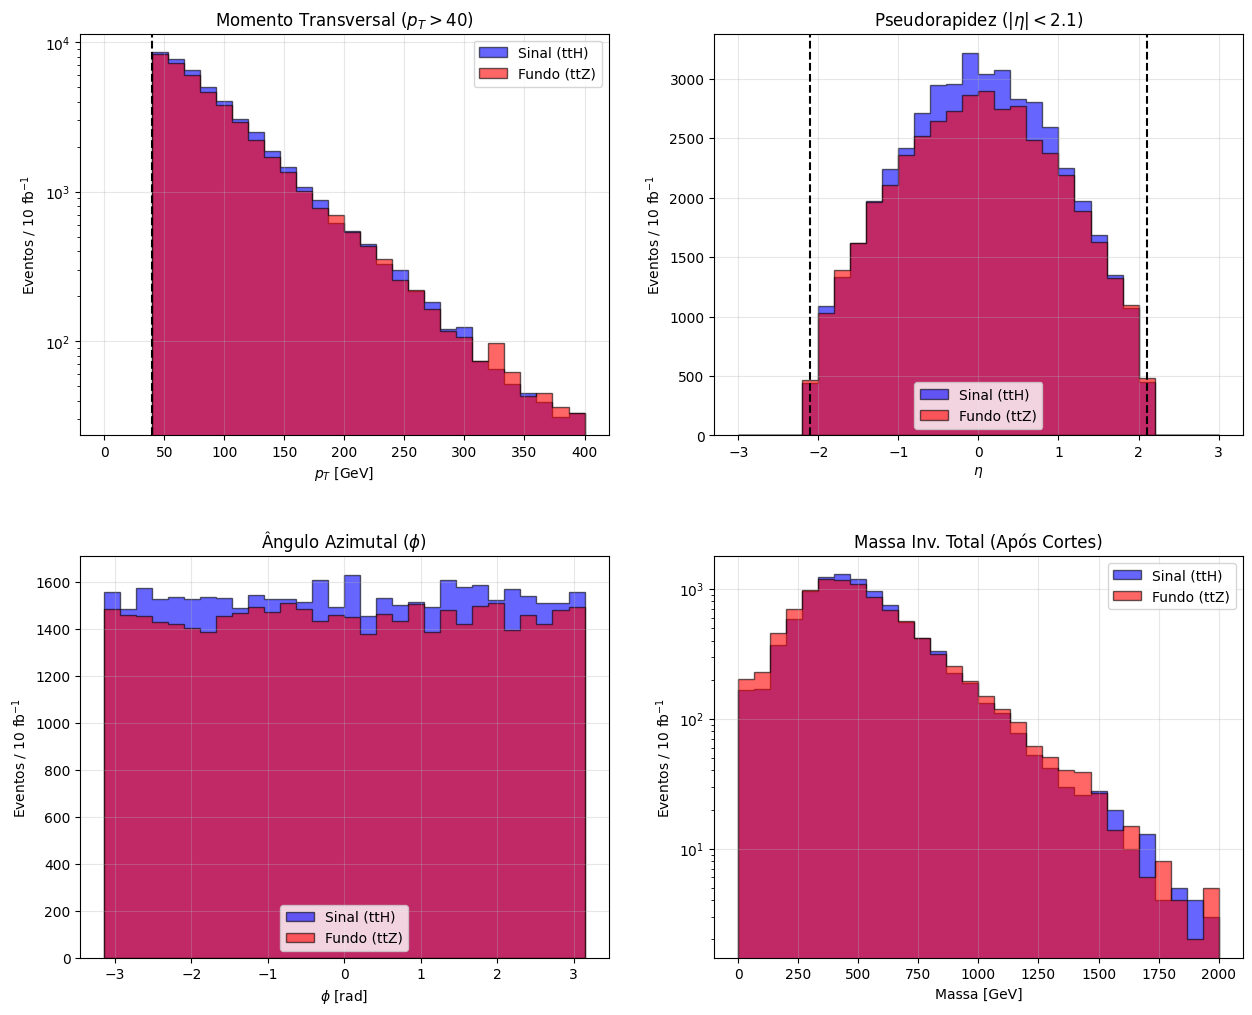

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gzip

# Configurações Gerais
LUMINOSIDADE = 10000.0  # pb^-1 (equivalente a 10 fb^-1)
BASE_PATH = 'fernando-matheus/data/' # Ajuste se necessário

def get_cross_section(filename):
    """Lê a seção de choque do arquivo LHE."""
    xsec_total = 0.0
    try:
        with gzip.open(filename, 'rt') as f:
            in_init = False
            for line in f:
                if '<init>' in line:
                    in_init = True
                    beam_line = next(f)
                    parts = beam_line.strip().split()
                    n_processes = int(parts[-1])
                    for _ in range(n_processes):
                        proc_line = next(f)
                        xsec_total += float(proc_line.strip().split()[0])
                    break
    except Exception as e:
        print(f"Aviso: Erro ao ler xsec de {filename}. Usando 1.0 pb.")
        return 1.0
    return xsec_total

# --- 1. Calcular Pesos (Baseado na amostra TOTAL) ---
file_sinal = f'{BASE_PATH}sinal.lhe.gz'
file_back  = f'{BASE_PATH}fundo.lhe.gz'

sigma_sinal = get_cross_section(file_sinal)
sigma_back  = get_cross_section(file_back)

# N_sim deve ser o número ORIGINAL de eventos gerados
n_sinal_sim = df_sinal['event_id'].nunique()
n_back_sim  = df_back['event_id'].nunique()

# Yield Total e Peso por evento gerado
yield_sinal = sigma_sinal * LUMINOSIDADE
yield_back  = sigma_back * LUMINOSIDADE

w_sinal = yield_sinal / n_sinal_sim
w_back  = yield_back / n_back_sim

print(f"SINAL (ttH): sigma={sigma_sinal:.4f}, Peso={w_sinal:.4f}")
print(f"FUNDO (ttZ): sigma={sigma_back:.4f}, Peso={w_back:.4f}")

# --- 2. Preparar Dados Selecionados (df_sel) ---
# Adiciona o peso aos dataframes JÁ CORTADOS (df_sinal_sel, df_back_sel)
df_sinal_sel = df_sinal_sel.copy()
df_back_sel = df_back_sel.copy()

df_sinal_sel['weight'] = w_sinal
df_back_sel['weight']  = w_back

# Recálculo de variáveis cinemáticas para plotagem (garantia)
for df in [df_sinal_sel, df_back_sel]:
    df['pt'] = np.sqrt(df['px']**2 + df['py']**2)
    p = np.sqrt(df['px']**2 + df['py']**2 + df['pz']**2)
    # Eta já deve ter sido calculado nos cortes, mas recalculamos por segurança
    df['eta'] = 0.5 * np.log((p + df['pz']) / (p - df['pz']))
    df['phi'] = np.arctan2(df['py'], df['px'])

# Recálculo da Massa Invariante Total (apenas para eventos selecionados)
def calc_mass_inv(df_in):
    if df_in.empty: return pd.Series(), pd.Series()
    # Agrupa por evento e soma quadrimomentos das partículas restantes
    g = df_in.groupby(['event_id', 'weight'])[['e', 'px', 'py', 'pz']].sum().reset_index()
    m2 = g['e']**2 - (g['px']**2 + g['py']**2 + g['pz']**2)
    return g['weight'], np.sqrt(m2.clip(lower=0))

w_mass_s, mass_s = calc_mass_inv(df_sinal_sel)
w_mass_b, mass_b = calc_mass_inv(df_back_sel)

# --- 3. Plotagem Normalizada (Com Cortes) ---
def plot_norm(ax, data_s, w_s, data_b, w_b, title, xlabel, bins=30, range_val=None, log=False):
    # Tratamento para pesos se arrays estiverem vazios ou desalinhados
    weights_s = data_s.shape[0]*[w_s.iloc[0]] if len(w_s.shape) > 0 and not w_s.empty else w_s if not w_s.empty else []
    weights_b = data_b.shape[0]*[w_b.iloc[0]] if len(w_b.shape) > 0 and not w_b.empty else w_b if not w_b.empty else []

    ax.hist(data_s, bins=bins, range=range_val, weights=weights_s,
            label='Sinal (ttH)', color='blue', alpha=0.6, histtype='stepfilled', edgecolor='black')
    ax.hist(data_b, bins=bins, range=range_val, weights=weights_b,
            label='Fundo (ttZ)', color='red', alpha=0.6, histtype='stepfilled', edgecolor='black')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f'Eventos / {LUMINOSIDADE/1000:.0f} fb$^{{-1}}$')
    ax.legend()
    ax.grid(alpha=0.3)
    if log: ax.set_yscale('log')

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3)

# 1. pT (Corte > 40 visível no gráfico)
plot_norm(axs[0,0], df_sinal_sel['pt'], df_sinal_sel['weight'], df_back_sel['pt'], df_back_sel['weight'],
          'Momento Transversal ($p_T > 40$)', '$p_T$ [GeV]', range_val=(0, 400), log=True)
axs[0,0].axvline(40, color='k', linestyle='--', label='Corte')

# 2. Eta (Corte |eta| < 2.1 visível)
plot_norm(axs[0,1], df_sinal_sel['eta'], df_sinal_sel['weight'], df_back_sel['eta'], df_back_sel['weight'],
          'Pseudorapidez ($|\eta| < 2.1$)', '$\eta$', range_val=(-3, 3))
axs[0,1].axvline(2.1, color='k', linestyle='--')
axs[0,1].axvline(-2.1, color='k', linestyle='--')

# 3. Phi
plot_norm(axs[1,0], df_sinal_sel['phi'], df_sinal_sel['weight'], df_back_sel['phi'], df_back_sel['weight'],
          'Ângulo Azimutal ($\phi$)', '$\phi$ [rad]', range_val=(-np.pi, np.pi))

# 4. Massa Invariante (Eventos selecionados)
plot_norm(axs[1,1], mass_s, w_mass_s, mass_b, w_mass_b,
          'Massa Inv. Total (Após Cortes)', 'Massa [GeV]', range_val=(0, 2000), log=True)

plt.show()

Calculando massas para histogramas empilhados...


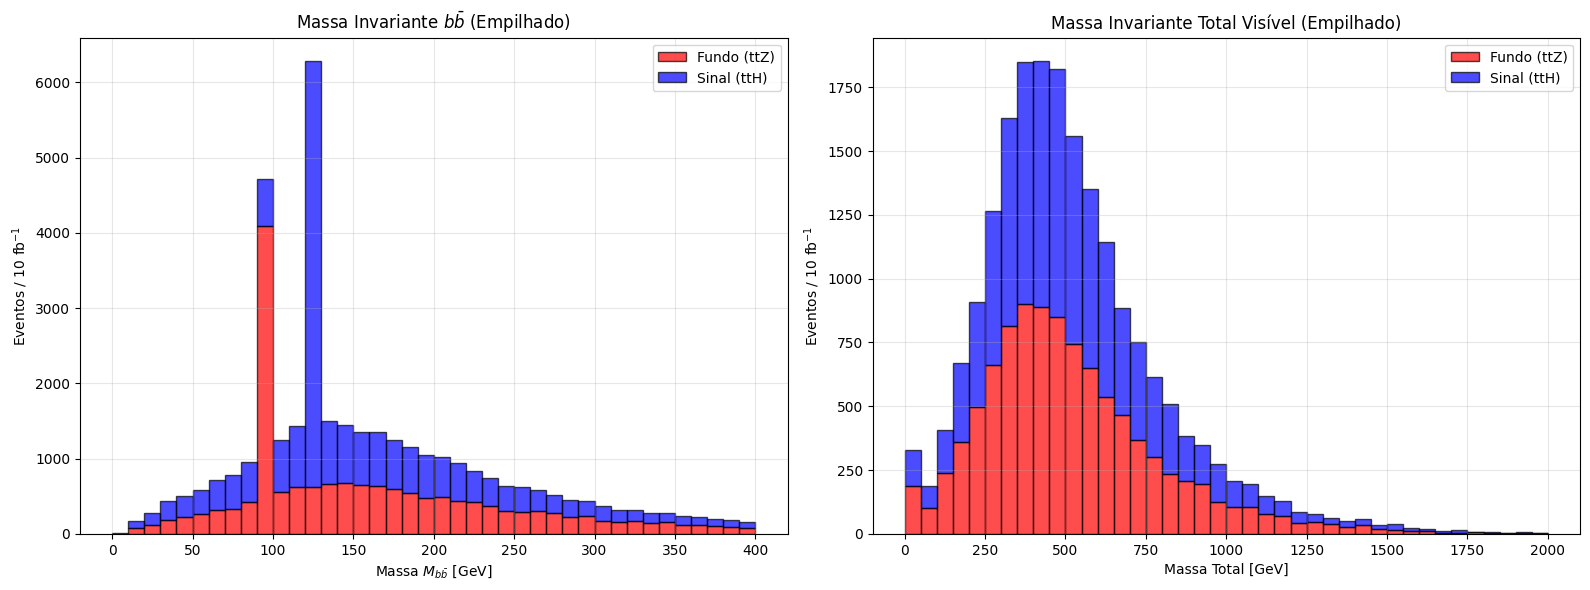

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# [7b] HISTOGRAMAS DE MASSA EMPILHADOS (STACKED)
# ==============================================================================

# Requer que as variáveis abaixo já estejam definidas nas células anteriores:
# - df_sinal_sel, df_back_sel (Dataframes com cortes aplicados e coluna 'weight')
# - LUMINOSIDADE (para label do eixo Y)

# --- 1. Função para calcular Massa Invariante de Pares b-bbar ---
def get_bb_mass(df):
    if df.empty: return pd.Series(dtype=float), pd.Series(dtype=float)

    # Filtrar b e bbar presentes nos eventos SELECIONADOS
    bs = df[df['pdg_id'] == 5]
    bbars = df[df['pdg_id'] == -5]

    # Merge para formar os pares dentro do mesmo evento
    # Mantemos 'weight' para usar na plotagem
    pairs = pd.merge(bs, bbars, on=['event_id', 'label', 'weight'], suffixes=('_1', '_2'))

    if pairs.empty: return pd.Series(dtype=float), pd.Series(dtype=float)

    # Quadrimomento do Par
    E  = pairs['e_1'] + pairs['e_2']
    Px = pairs['px_1'] + pairs['px_2']
    Py = pairs['py_1'] + pairs['py_2']
    Pz = pairs['pz_1'] + pairs['pz_2']

    # Massa Invariante
    M2 = E**2 - (Px**2 + Py**2 + Pz**2)
    return pairs['weight'], np.sqrt(M2.clip(lower=0))

# --- 2. Função para calcular Massa Invariante Total (Visível) ---
def get_total_mass(df):
    if df.empty: return pd.Series(dtype=float), pd.Series(dtype=float)

    # Agrupar por evento e somar tudo
    g = df.groupby(['event_id', 'weight'])[['e', 'px', 'py', 'pz']].sum().reset_index()

    M2 = g['e']**2 - (g['px']**2 + g['py']**2 + g['pz']**2)
    return g['weight'], np.sqrt(M2.clip(lower=0))

# --- 3. Cálculos ---
print("Calculando massas para histogramas empilhados...")

# Massa bb
w_bb_sinal, m_bb_sinal = get_bb_mass(df_sinal_sel)
w_bb_back, m_bb_back   = get_bb_mass(df_back_sel)

# Massa Total
w_tot_sinal, m_tot_sinal = get_total_mass(df_sinal_sel)
w_tot_back, m_tot_back   = get_total_mass(df_back_sel)

# --- 4. Plotagem Empilhada ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Configuração de cores e labels
colors = ['red', 'blue']
labels = ['Fundo (ttZ)', 'Sinal (ttH)']

# Plot 1: Massa Invariante b-bbar
# Passamos listas de dados e listas de pesos. O matplotlib empilha automaticamente com stacked=True
axs[0].hist([m_bb_back, m_bb_sinal],
            weights=[w_bb_back, w_bb_sinal],
            bins=40, range=(0, 400),
            stacked=True,
            color=colors, label=labels,
            alpha=0.7, edgecolor='black')

axs[0].set_title("Massa Invariante $b\\bar{b}$ (Empilhado)")
axs[0].set_xlabel("Massa $M_{b\\bar{b}}$ [GeV]")
axs[0].set_ylabel(f"Eventos / {LUMINOSIDADE/1000:.0f} fb$^{{-1}}$")
axs[0].legend()
axs[0].grid(alpha=0.3)

# Plot 2: Massa Invariante Total
axs[1].hist([m_tot_back, m_tot_sinal],
            weights=[w_tot_back, w_tot_sinal],
            bins=40, range=(0, 2000),
            stacked=True,
            color=colors, label=labels,
            alpha=0.7, edgecolor='black')

axs[1].set_title("Massa Invariante Total Visível (Empilhado)")
axs[1].set_xlabel("Massa Total [GeV]")
axs[1].set_ylabel(f"Eventos / {LUMINOSIDADE/1000:.0f} fb$^{{-1}}$")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## [8] COMENTÁRIOS

Faz sentido a proporção entre os histogramas normalizados com base na seção de choque presente nos arquivos LHE?
Você verifica alguma estrutura particular nas disitrubuições de massa invariante?

Resposta:

A proporção dos histogramas faz sentido. Antes de aplicar a normalização a seção de choque e, portanto, a luminosidade do fundo e do sinal eram diferentes. Ao aplicar a normalização com base na seção de choque observamos uma proporção entre o fundo e o sinal. Ambos histogramas apresentam um fundo contínuo, com picos nas suas respectivas massas. O pico e os valores contínuos do sinal são maiores que do fundo, a razão disso é que os cortes aplicados anteriormente retiraram alguns dos eventos de fundo, fazendo aparecer mais eventos correspondente ao sinal.

Existe uma estrutura relevante na distribuição da massa invariante, porque os plots apresentam dois picos em valores distindos. Em aproximadamente 91 GeV existe um pico devido a contribuição do fundo. Esse pico é a contribuição da massa do Bóson Z, justamente a partícula correspondente ao processo identificado anteriormente. Analogamente, existe um pico em 125 GeV, dessa vez pela contribuição do sinal. Pelo mesmo motivo, esse pico é devido a massa do bóson de Higgs, como esperado, já que foi identificado que o arquivo de sinal corresponde a um processo envolvendo Higgs.